In [2]:
import moocore
import pandas as pd
from pymoo.indicators.hv import HV
import numpy as np

In [6]:
df = pd.read_csv('results.csv')

dados_HV = {}

# 1. Escolher um dataset e definir o ponto de referência
dataset_alvo = ['imdb', 'amazon', 'rotten_tomatoes']

for d in dataset_alvo:
    ref_point = np.array([0.0, 0.0, 0.0]) # [hr@10, ndcg@10, mrr]
    ind = moocore.Hypervolume(ref=ref_point, maximise=True)

    modelos = df['model'].unique()
    resultados_hv = {}

    for m in modelos:
        # 2. Filtrar dados do modelo e dataset
        subset = df[(df['model'] == m) & (df['datasets'] == d)]

        # 3. Extrair as métricas (as 3 dimensões)
        pontos = subset[['hit_rate', 'ndcg', 'mrr']].values

        # 4. Calcular o Hypervolume acumulado pelos folds
        # Nota: O HV aqui mostrará a estabilidade/performance do modelo
        volume = ind(pontos)
        resultados_hv[m] = volume

    dados_HV[d] = resultados_hv

dados_HV = pd.DataFrame(dados_HV)
dados_HV

,imdb,amazon,rotten_tomatoes
bpr_pure,0.001888,0.010093,0.040344
contrastive,0.001352,0.006233,0.111873
hybrid,0.003366,0.007067,0.115147


In [9]:
# df = pd.read_csv('./resultado_metricas.csv')

ref_point = np.array([0.0, 0.0, 0.0]) # [hr@10, ndcg@10, mrr]
ind = moocore.Hypervolume(ref=ref_point, maximise=True)
df['HV'] = df.apply(lambda x: ind(np.array([[x['hit_rate'], x['ndcg'], x['mrr']]])), axis=1)
df

,model,datasets,fold,hit_rate,ndcg,mrr,HV
0,bpr_pure,amazon,0,0.286319,0.173250,0.155317,0.007705
1,bpr_pure,amazon,1,0.309984,0.190472,0.170022,0.010039
2,bpr_pure,amazon,2,0.308972,0.190988,0.170490,0.010061
3,bpr_pure,amazon,3,0.306447,0.189243,0.169644,0.009838
4,bpr_pure,amazon,4,0.297218,0.184428,0.167026,0.009156
5,bpr_pure,imdb,0,0.162351,0.090910,0.092270,0.001362
6,bpr_pure,imdb,1,0.158572,0.085710,0.087101,0.001184
7,bpr_pure,imdb,2,0.153114,0.082476,0.082910,0.001047
8,bpr_pure,imdb,3,0.158852,0.086444,0.087926,0.001207
9,bpr_pure,imdb,4,0.188383,0.100750,0.099462,0.001888


--- Teste de Normalidade (Global) ---
Shapiro-Wilk: p-value = 7.6025e-09 (Não-Normal)

Número de blocos (Dataset + Folds) analisados: 15
Modelos comparados: ['bpr_pure', 'contrastive', 'hybrid']

--- Teste de Friedman (Todos os Datasets) ---
Estatística: 9.7333
p-value: 7.6990e-03

--- Ranking Médio Global ---
model
hybrid         1.400000
bpr_pure       2.066667
contrastive    2.533333
dtype: float64 



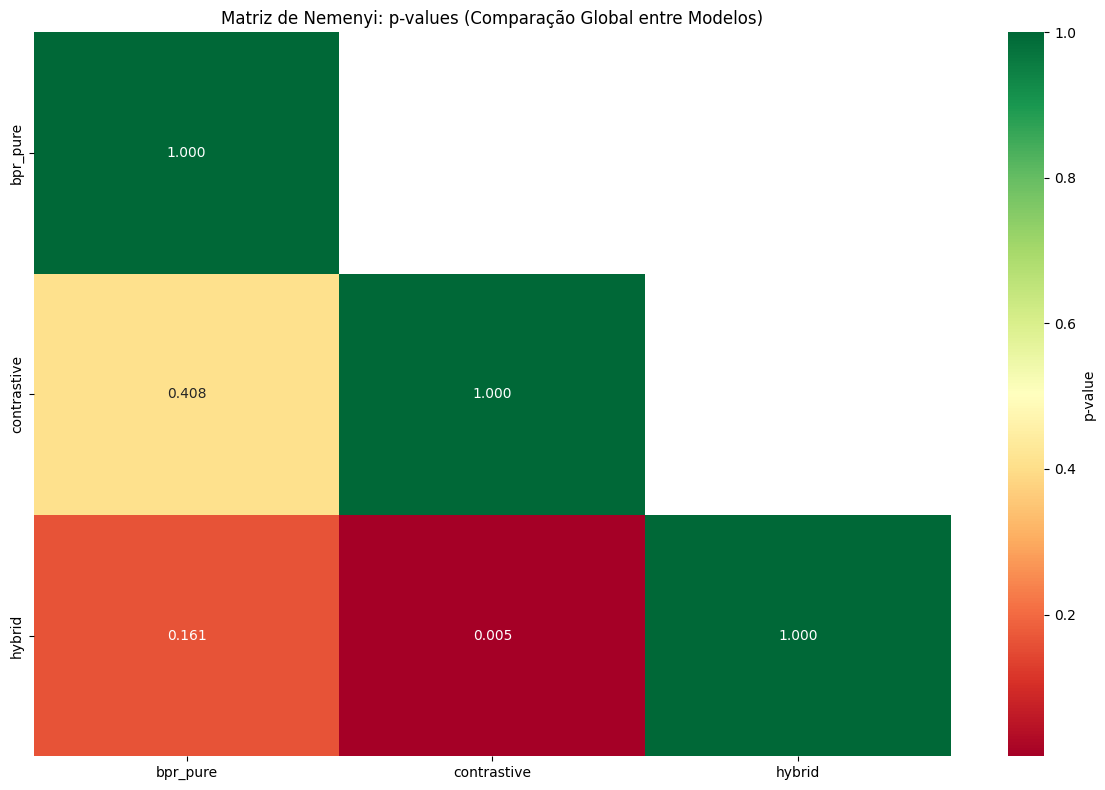

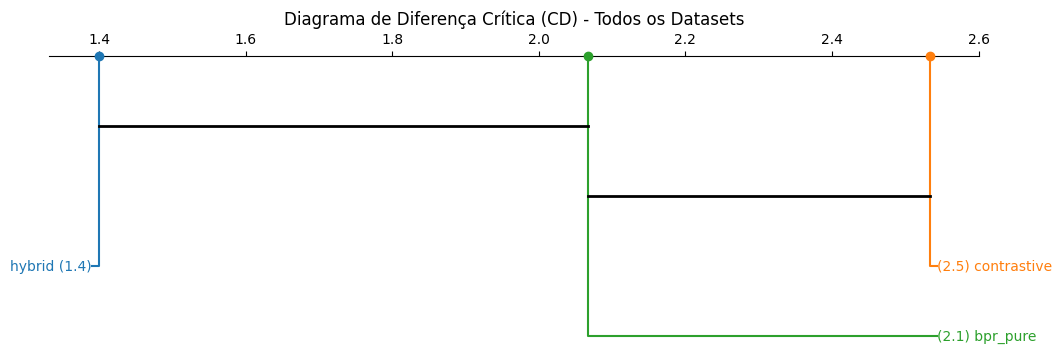

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, friedmanchisquare
import scikit_posthocs as sp

# 1. Preparação dos Dados
df = pd.read_csv('results.csv')

# Cálculo do Hypervolume (Produto das métricas de maximização)
def calculate_hv(row):
    return row['hit_rate'] * row['ndcg'] * row['mrr']

df['HV'] = df.apply(calculate_hv, axis=1)

# 2. Teste de Normalidade Global (Shapiro-Wilk)
stat, p_norm = shapiro(df['HV'])
print(f"--- Teste de Normalidade (Global) ---")
print(f"Shapiro-Wilk: p-value = {p_norm:.4e} ({'Normal' if p_norm > 0.05 else 'Não-Normal'})\n")

# 3. Preparação da Matriz de Friedman (Considerando Todos os Datasets)
# Criamos uma chave única combinando Dataset e Fold para serem nossos 'blocos'
df['block'] = df['datasets'] + "_f" + df['fold'].astype(str)

# Pivotamos: Linhas são as combinações Dataset/Fold, Colunas são os Modelos
pivot_df = df.pivot_table(index='block', columns='model', values='HV')

# O Friedman exige que não haja NaNs. Vamos remover blocos onde nem todos os modelos rodaram
pivot_df = pivot_df.dropna()

print(f"Número de blocos (Dataset + Folds) analisados: {len(pivot_df)}")
print(f"Modelos comparados: {list(pivot_df.columns)}\n")

# 4. Teste de Friedman
stat_f, p_f = friedmanchisquare(*[pivot_df[col] for col in pivot_df.columns])
print(f"--- Teste de Friedman (Todos os Datasets) ---")
print(f"Estatística: {stat_f:.4f}")
print(f"p-value: {p_f:.4e}\n")

# 5. Post-hoc Nemenyi e Visualizações
if p_f < 0.05:
    # Detalhamento do Rank (Maiores valores de HV recebem os melhores postos)
    # rank(ascending=False) garante que o maior HV seja rank 1
    ranks = pivot_df.rank(axis=1, ascending=False).mean().sort_values()
    print("--- Ranking Médio Global ---")
    print(ranks, "\n")

    # Cálculo da Matriz de Nemenyi
    nemenyi_matrix = sp.posthoc_nemenyi_friedman(pivot_df)

    # PLOT 1: Mapa de Calor da Matriz de Nemenyi
    plt.figure(figsize=(12, 8))
    sns.heatmap(nemenyi_matrix, annot=True, cmap='RdYlGn', fmt=".3f",
                cbar_kws={'label': 'p-value'}, mask=np.triu(np.ones_like(nemenyi_matrix, dtype=bool), k=1))
    plt.title('Matriz de Nemenyi: p-values (Comparação Global entre Modelos)')
    plt.tight_layout()
    plt.show()

    # PLOT 2: Gráfico de Diferença Crítica (CD Diagram)
    # Este gráfico é o mais importante para visualizar a performance entre datasets
    plt.figure(figsize=(12, 4))
    sp.critical_difference_diagram(ranks, nemenyi_matrix)
    plt.title("Diagrama de Diferença Crítica (CD) - Todos os Datasets")
    plt.show()
else:
    print("O teste de Friedman não encontrou diferenças significativas entre os modelos considerando todos os datasets.")